In [ ]:
# Import and Read the Survey Catalogue
data = galah[1].data

df = pd.DataFrame(data)

df.head()

NameError: name 'galah' is not defined

In [ ]:
# Named two variables for the columns
print(df.columns.tolist())
print(gaia_df.columns.tolist())

NameError: name 'df' is not defined

In [ ]:
# Test run the merged columns
print(merged.columns.tolist())

['star_id_x', 'sobject_id_x', 'dr2_source_id_x', 'dr3_source_id', 'survey_name', 'field_id', 'flag_repeat', 'wg4_field', 'wg4_pipeline', 'flag_sp', 'teff', 'e_teff', 'irfm_teff', 'irfm_ebv', 'irfm_ebv_ref', 'logg', 'e_logg', 'fe_h', 'e_fe_h', 'flag_fe_h', 'fe_h_atmo', 'vmic', 'vbroad', 'e_vbroad', 'chi2_sp', 'alpha_fe', 'e_alpha_fe', 'nr_alpha_fe', 'flag_alpha_fe', 'flux_A_Fe', 'chi_A_Fe', 'Li_fe', 'e_Li_fe', 'nr_Li_fe', 'flag_Li_fe', 'C_fe', 'e_C_fe', 'nr_C_fe', 'flag_C_fe', 'O_fe', 'e_O_fe', 'nr_O_fe', 'flag_O_fe', 'Na_fe', 'e_Na_fe', 'nr_Na_fe', 'flag_Na_fe', 'Mg_fe', 'e_Mg_fe', 'nr_Mg_fe', 'flag_Mg_fe', 'Al_fe', 'e_Al_fe', 'nr_Al_fe', 'flag_Al_fe', 'Si_fe', 'e_Si_fe', 'nr_Si_fe', 'flag_Si_fe', 'K_fe', 'e_K_fe', 'nr_K_fe', 'flag_K_fe', 'Ca_fe', 'e_Ca_fe', 'nr_Ca_fe', 'flag_Ca_fe', 'Sc_fe', 'e_Sc_fe', 'nr_Sc_fe', 'flag_Sc_fe', 'Sc2_fe', 'e_Sc2_fe', 'nr_Sc2_fe', 'flag_Sc2_fe', 'Ti_fe', 'e_Ti_fe', 'nr_Ti_fe', 'flag_Ti_fe', 'Ti2_fe', 'e_Ti2_fe', 'nr_Ti2_fe', 'flag_Ti2_fe', 'V_fe', 'e_V_

In [ ]:
# Eliminate rows with missing values in the core columns
analysis_df=analysis_df.dropna(subset=["ra", "dec", "pmra", "pmdec", "fe_h", "rv_galah", "parallax", "l", "b"])

# Quick check of the cleaned data
analysis_df.head()
print("Number of stars after cleaning:", len(analysis_df))


Number of stars after cleaning: 649172


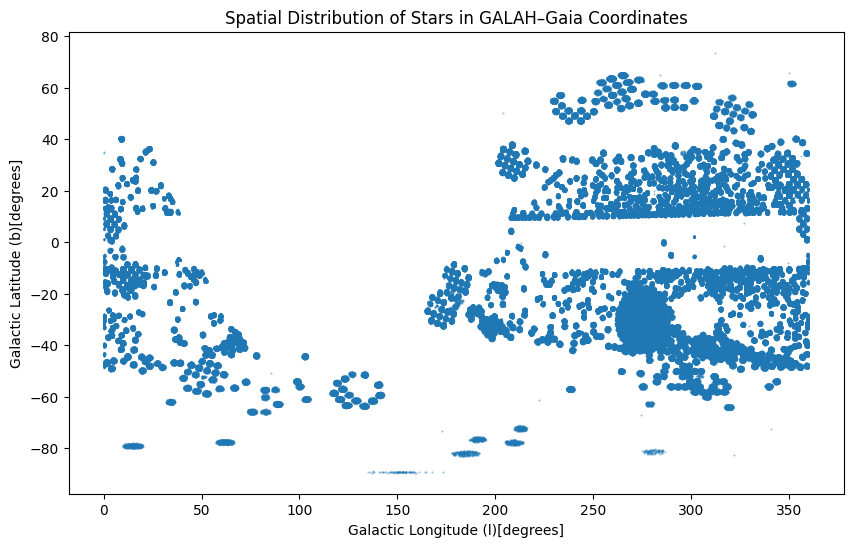

In [ ]:
# =========================
# 3. Sky distribution
# =========================
# Data looks good so far, proceeding to the next steps of the analysis and plotting.
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(
    analysis_df["l"],
    analysis_df["b"],
    s=0.3,
    alpha=0.4
)

plt.xlabel("Galactic Longitude (l)[degrees]")
plt.ylabel("Galactic Latitude (b)[degrees]")
plt.title("Spatial Distribution of Stars in GALAH–Gaia Coordinates")
plt.show()


In [ ]:
# Define and classify stellar populations by metallicity

disk=analysis_df[analysis_df["fe_h"] > -0.5].copy()
thick_disk=analysis_df[(analysis_df["fe_h"] <= -0.5) & (analysis_df["fe_h"] > -1.0)].copy()
halo=analysis_df[analysis_df["fe_h"] <= -1.0].copy()
print("Disk stars:",len(disk))
print("Thick disk stars:",len(thick_disk))
print("Halo stars:",len(halo))


Disk stars: 484933
Thick disk stars: 65488
Halo stars: 15445


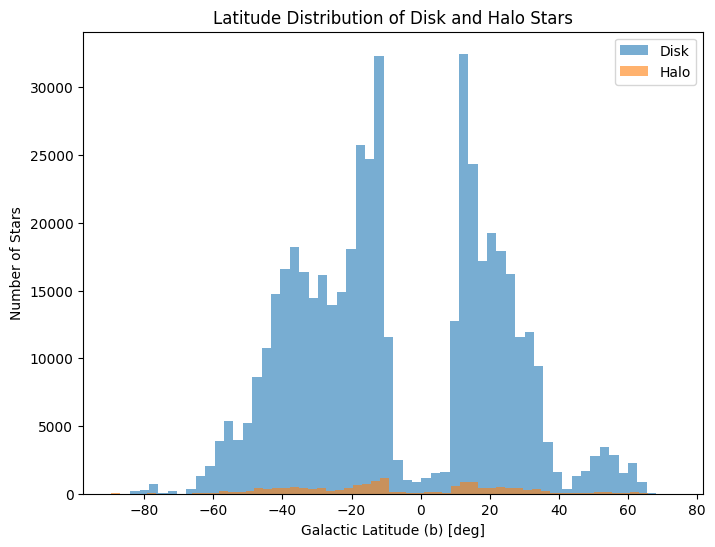

In [ ]:
# Since we have a large number of stars, we can also plot the latitude distribution of the disk and halo stars to better visualize the differences in their spatial distributions.
plt.figure(figsize=(8,6))

plt.hist(disk["b"], bins=60, alpha=0.6, label="Disk")
plt.hist(halo["b"], bins=60, alpha=0.6, label="Halo")

plt.xlabel("Galactic Latitude (b) [deg]")
plt.ylabel("Number of Stars")
plt.title("Latitude Distribution of Disk and Halo Stars")

plt.legend()
plt.show()